In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [5]:
#load the data set

customers = pd.read_csv("customers.csv")

customers.head()

,CustomerID,Age,Gender,Occupation,MonthlyIncome,Region,Branch,FCYAccount,ETBAccount,MobileBanking,InternetBanking,RemittanceCount,TotalRemittanceUSD,AverageTransactionUSD,FCYPurchaseUSD,LastTransactionDays,ExistingProducts,LeadStatus
0,100001,59,Female,Business Owner,71321,Addis Ababa,Adama,Yes,Yes,Yes,No,5,5145,857.50,2167,166,2,0
1,100002,49,Male,Merchant,144028,Amhara,CMC,No,Yes,No,No,8,8416,935.11,1779,150,5,0
2,100003,35,Female,Teacher,86131,Addis Ababa,Bole,No,Yes,Yes,No,5,5925,987.50,2163,363,2,0
3,100004,63,Female,Merchant,37963,Tigray,Megenagna,Yes,Yes,No,Yes,5,3815,635.83,1569,343,3,0
4,100005,28,Male,Private Employee,113757,Amhara,CMC,No,Yes,No,No,3,3033,758.25,1615,68,3,0


In [6]:
#check the dataset shape
print("Rows:", customers.shape[0])
print("Columns:", customers.shape[1])

Rows: 500
Columns: 18


In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             500 non-null    int64  
 1   Age                    500 non-null    int64  
 2   Gender                 500 non-null    object 
 3   Occupation             500 non-null    object 
 4   MonthlyIncome          500 non-null    int64  
 5   Region                 500 non-null    object 
 6   Branch                 500 non-null    object 
 7   FCYAccount             500 non-null    object 
 8   ETBAccount             500 non-null    object 
 9   MobileBanking          500 non-null    object 
 10  InternetBanking        500 non-null    object 
 11  RemittanceCount        500 non-null    int64  
 12  TotalRemittanceUSD     500 non-null    int64  
 13  AverageTransactionUSD  500 non-null    float64
 14  FCYPurchaseUSD         500 non-null    int64  
 15  LastTr

In [8]:
customers.describe()

,CustomerID,Age,MonthlyIncome,RemittanceCount,TotalRemittanceUSD,AverageTransactionUSD,FCYPurchaseUSD,LastTransactionDays,ExistingProducts,LeadStatus
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.000000,500.000000,500.000000
mean,100250.500000,45.678000,96199.626000,6.872000,5305.636000,662.85804,2995.03800,180.908000,3.064000,0.186000
std,144.481833,14.127898,48703.501743,2.659655,2684.562809,223.23882,1936.91436,106.852733,1.417011,0.389496
min,100001.000000,21.000000,12163.000000,1.000000,318.000000,159.00000,134.00000,1.000000,1.000000,0.000000
25%,100125.750000,34.000000,51062.750000,5.000000,3241.000000,474.41250,1613.50000,90.750000,2.000000,0.000000
50%,100250.500000,46.000000,95889.000000,7.000000,4988.500000,680.77500,2560.50000,173.000000,3.000000,0.000000
75%,100375.250000,57.000000,137731.750000,8.250000,6972.000000,848.47000,3954.25000,273.000000,4.000000,0.000000
max,100500.000000,69.000000,179523.000000,17.000000,15570.000000,1089.09000,11130.00000,363.000000,5.000000,1.000000


In [9]:
#check missing value
customers.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
Occupation               0
MonthlyIncome            0
Region                   0
Branch                   0
FCYAccount               0
ETBAccount               0
MobileBanking            0
InternetBanking          0
RemittanceCount          0
TotalRemittanceUSD       0
AverageTransactionUSD    0
FCYPurchaseUSD           0
LastTransactionDays      0
ExistingProducts         0
LeadStatus               0
dtype: int64

In [10]:
#check duplicate records
customers.duplicated().sum()

np.int64(0)

In [11]:
customers.head(10)

,CustomerID,Age,Gender,Occupation,MonthlyIncome,Region,Branch,FCYAccount,ETBAccount,MobileBanking,InternetBanking,RemittanceCount,TotalRemittanceUSD,AverageTransactionUSD,FCYPurchaseUSD,LastTransactionDays,ExistingProducts,LeadStatus
0,100001,59,Female,Business Owner,71321,Addis Ababa,Adama,Yes,Yes,Yes,No,5,5145,857.50,2167,166,2,0
1,100002,49,Male,Merchant,144028,Amhara,CMC,No,Yes,No,No,8,8416,935.11,1779,150,5,0
2,100003,35,Female,Teacher,86131,Addis Ababa,Bole,No,Yes,Yes,No,5,5925,987.50,2163,363,2,0
3,100004,63,Female,Merchant,37963,Tigray,Megenagna,Yes,Yes,No,Yes,5,3815,635.83,1569,343,3,0
4,100005,28,Male,Private Employee,113757,Amhara,CMC,No,Yes,No,No,3,3033,758.25,1615,68,3,0
5,100006,41,Male,Private Employee,111259,Harari,Hawassa,Yes,Yes,No,Yes,6,6162,880.29,2023,221,1,0
6,100007,59,Female,Private Employee,51063,Sidama,Piassa,Yes,Yes,Yes,No,9,9144,914.40,7817,271,3,0
7,100008,39,Male,Business Owner,126225,Tigray,CMC,No,Yes,No,No,9,6435,643.50,4689,321,2,0
8,100009,43,Male,Business Owner,128400,Dire Dawa,Mexico,No,Yes,Yes,Yes,6,3090,441.43,815,310,1,0
9,100010,31,Female,Doctor,92818,Harari,Mexico,No,Yes,Yes,No,6,2274,324.86,1563,349,3,0


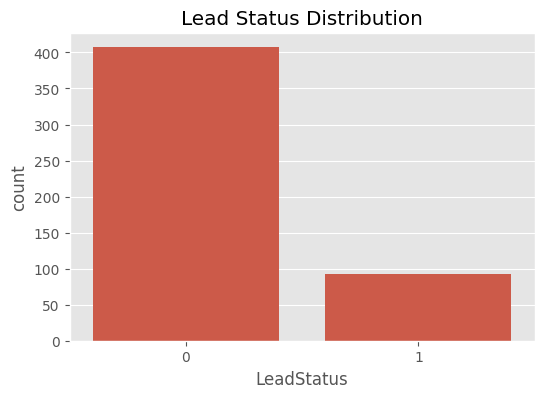

In [12]:
#target variable distribution
customers["LeadStatus"].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(
    data=customers,
    x="LeadStatus"
)

plt.title("Lead Status Distribution")

plt.show()

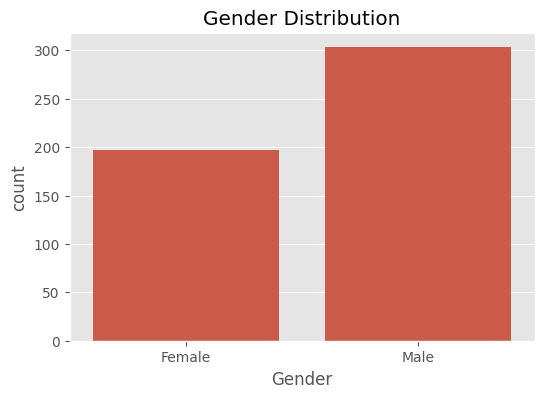

In [13]:
#customer gender distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=customers,
    x="Gender"
)

plt.title("Gender Distribution")

plt.show()

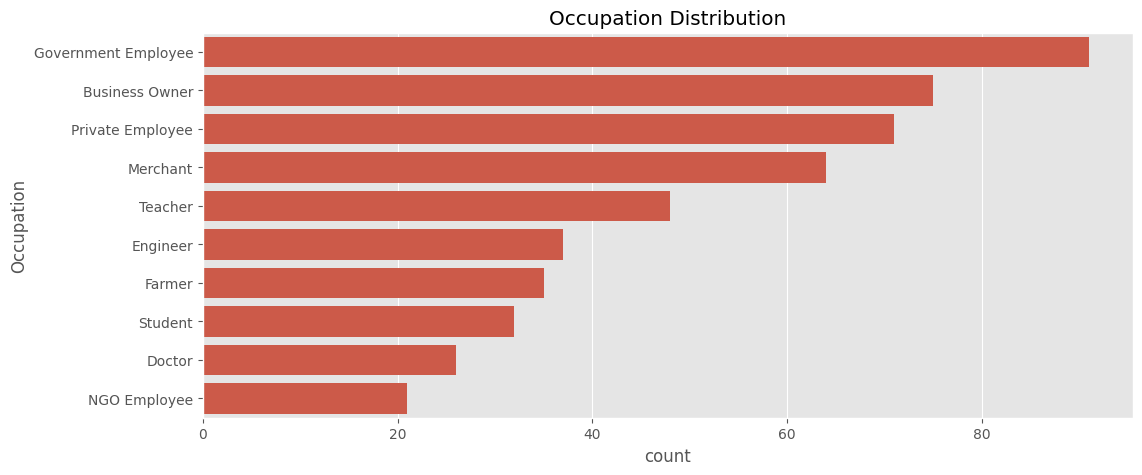

In [14]:
#occupation distribution

plt.figure(figsize=(12,5))

sns.countplot(
    data=customers,
    y="Occupation",
    order=customers["Occupation"].value_counts().index
)

plt.title("Occupation Distribution")

plt.show()

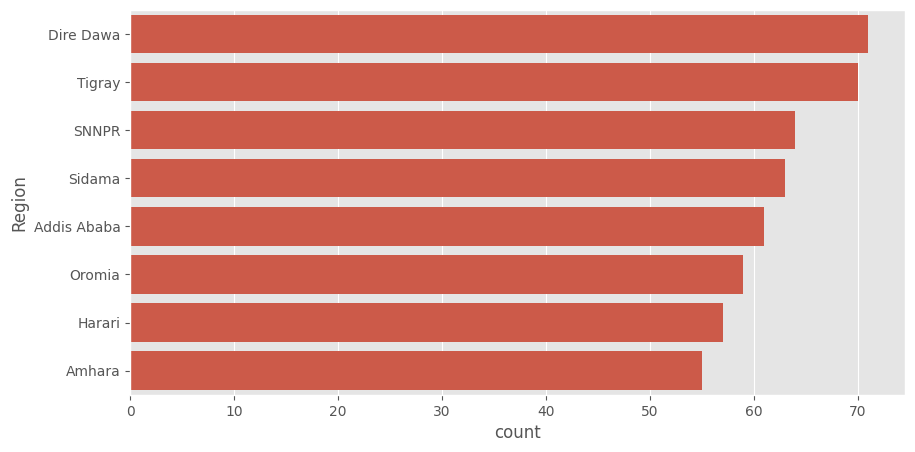

In [15]:
#region distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    y="Region",
    order=customers["Region"].value_counts().index
)

plt.show()

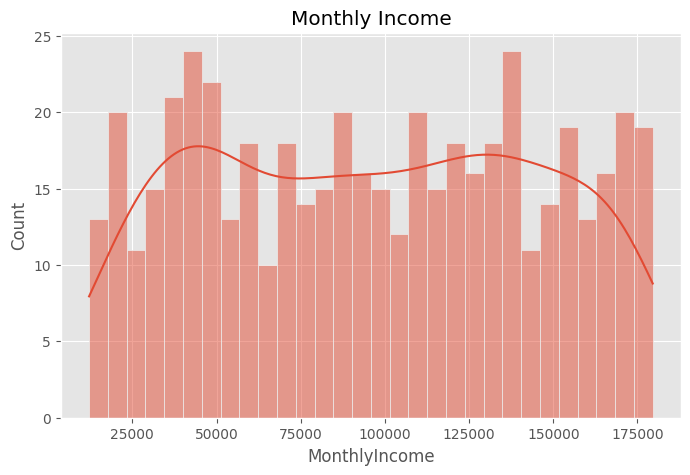

In [16]:
#monthly income distribution
plt.figure(figsize=(8,5))

sns.histplot(
    customers["MonthlyIncome"],
    bins=30,
    kde=True
)

plt.title("Monthly Income")

plt.show()

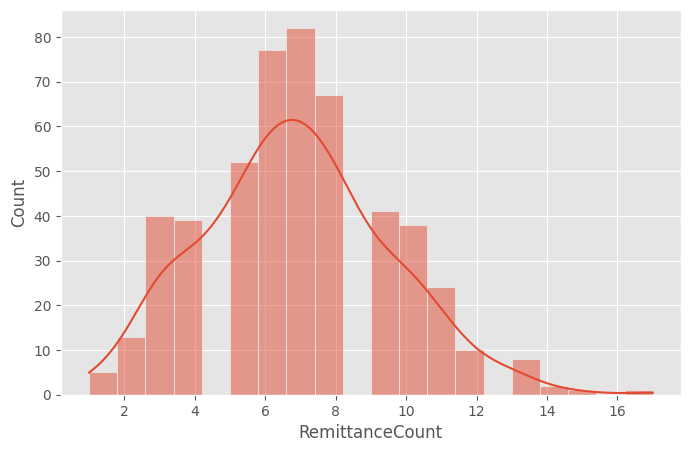

In [17]:
#remmitance count distribution
plt.figure(figsize=(8,5))

sns.histplot(
    customers["RemittanceCount"],
    bins=20,
    kde=True
)

plt.show()

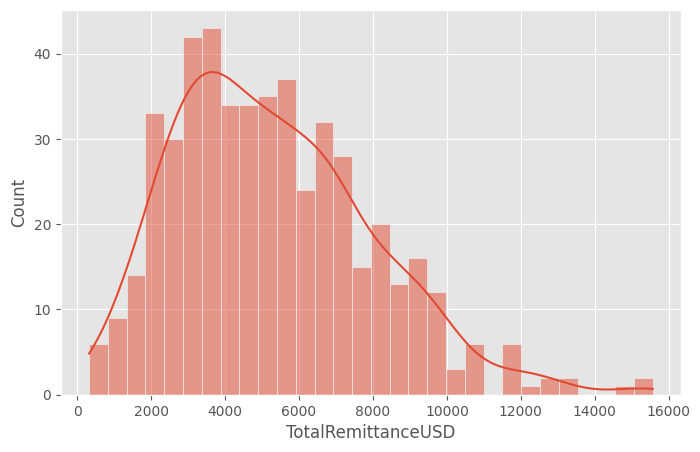

In [18]:
#total remmitance distribution
plt.figure(figsize=(8,5))

sns.histplot(
    customers["TotalRemittanceUSD"],
    bins=30,
    kde=True
)

plt.show()

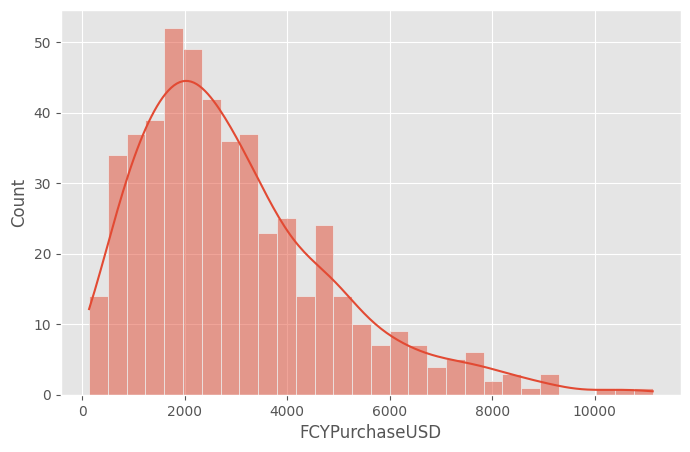

In [19]:
#fcy purchase distribution
plt.figure(figsize=(8,5))

sns.histplot(
    customers["FCYPurchaseUSD"],
    bins=30,
    kde=True
)

plt.show()

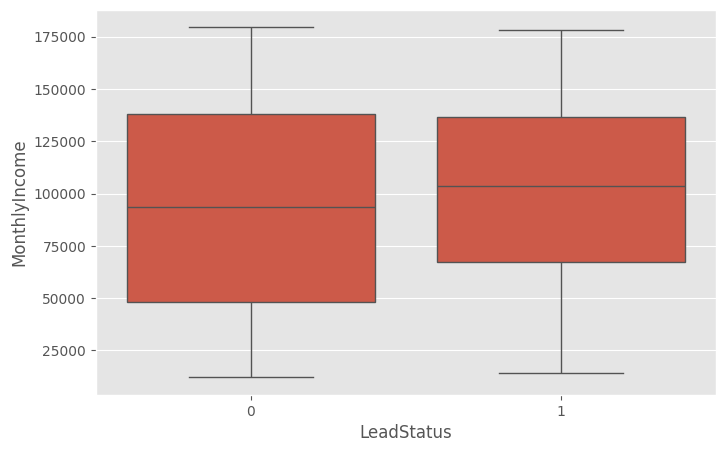

In [20]:
#leads vs non-leads income
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers,
    x="LeadStatus",
    y="MonthlyIncome"
)

plt.show()

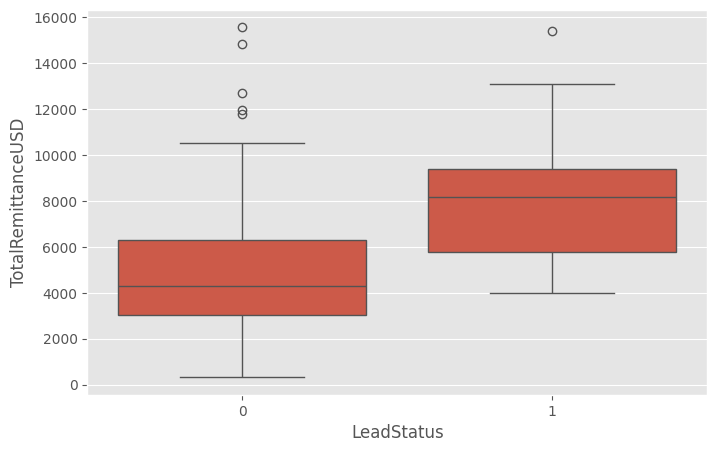

In [21]:
#lead vs remmitance
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers,
    x="LeadStatus",
    y="TotalRemittanceUSD"
)

plt.show()

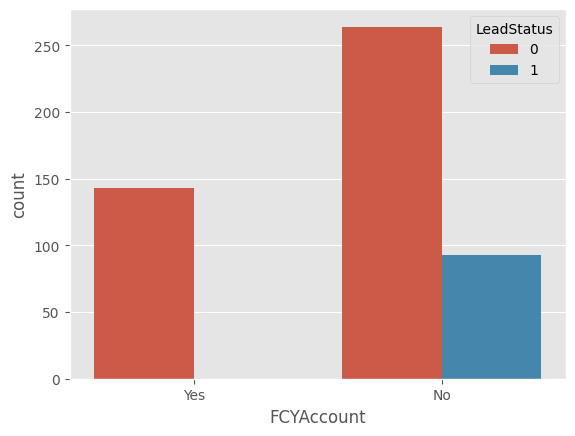

In [22]:
#fcy account vs lead
pd.crosstab(

customers["FCYAccount"],

customers["LeadStatus"]

)

sns.countplot(
    data=customers,
    x="FCYAccount",
    hue="LeadStatus"
)

plt.show()

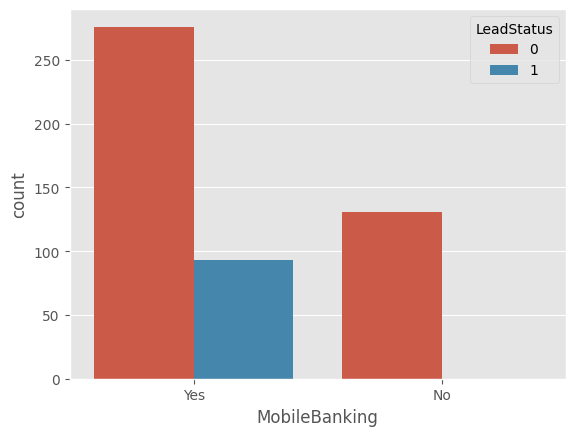

In [23]:
#mobile banking vs lead

pd.crosstab(

customers["MobileBanking"],

customers["LeadStatus"]

)

sns.countplot(
    data=customers,
    x="MobileBanking",
    hue="LeadStatus"
)

plt.show()

In [24]:
#correlation analysis

numeric_columns = customers.select_dtypes(include=["int64", "float64"])

numeric_columns.head()

,CustomerID,Age,MonthlyIncome,RemittanceCount,TotalRemittanceUSD,AverageTransactionUSD,FCYPurchaseUSD,LastTransactionDays,ExistingProducts,LeadStatus
0,100001,59,71321,5,5145,857.50,2167,166,2,0
1,100002,49,144028,8,8416,935.11,1779,150,5,0
2,100003,35,86131,5,5925,987.50,2163,363,2,0
3,100004,63,37963,5,3815,635.83,1569,343,3,0
4,100005,28,113757,3,3033,758.25,1615,68,3,0


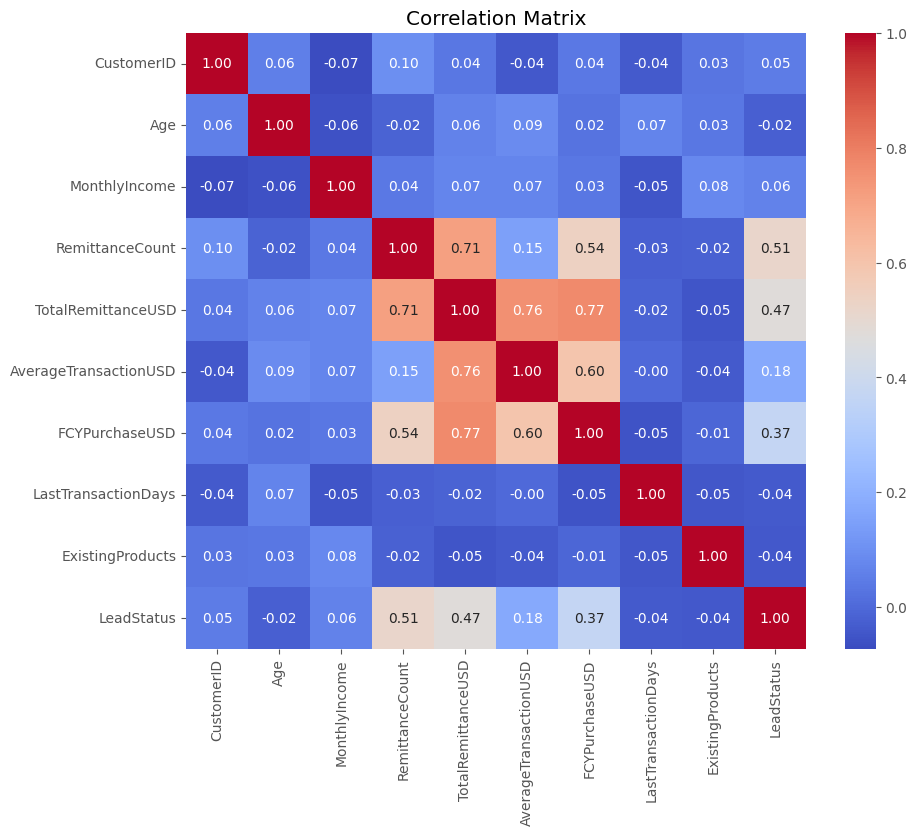

In [25]:
#correlation matrix
corr = numeric_columns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [26]:
#Top 10 Customers by Remittance
top_customers = customers.sort_values(
    by="TotalRemittanceUSD",
    ascending=False
)

top_customers.head(10)

,CustomerID,Age,Gender,Occupation,MonthlyIncome,Region,Branch,FCYAccount,ETBAccount,MobileBanking,InternetBanking,RemittanceCount,TotalRemittanceUSD,AverageTransactionUSD,FCYPurchaseUSD,LastTransactionDays,ExistingProducts,LeadStatus
57,100058,55,Male,Teacher,130154,Dire Dawa,Bole,No,Yes,No,Yes,15,15570,973.12,3376,206,5,0
77,100078,35,Female,Merchant,38155,Amhara,Bole,No,No,Yes,Yes,14,15386,1025.73,9004,196,4,1
289,100290,23,Female,Student,103658,Oromia,Megenagna,Yes,Yes,Yes,No,13,14820,1058.57,6604,28,2,0
412,100413,36,Female,Merchant,142513,Harari,Adama,No,Yes,Yes,Yes,13,13104,936.00,8371,221,4,1
89,100090,45,Female,Government Employee,144130,Oromia,Megenagna,No,No,Yes,Yes,12,13092,1007.08,8447,265,1,1
303,100304,45,Male,Teacher,121847,Amhara,Mexico,Yes,Yes,Yes,No,12,12720,978.46,5055,154,1,0
448,100449,62,Male,Student,54913,Sidama,Piassa,No,Yes,Yes,Yes,12,12672,974.77,7420,233,1,1
419,100420,22,Female,Student,130947,Sidama,CMC,No,Yes,Yes,No,13,12142,867.29,8785,11,4,1
99,100100,44,Female,Business Owner,144311,Tigray,Hawassa,No,Yes,Yes,Yes,10,11980,1089.09,10481,321,1,1
95,100096,21,Male,Doctor,45997,Harari,Mexico,Yes,Yes,Yes,No,10,11980,1089.09,10319,246,3,0


In [27]:
#lead percentage
lead_percentage = (
    customers["LeadStatus"].mean() * 100
)

print(f"Lead Percentage: {lead_percentage:.2f}%")

Lead Percentage: 18.60%


In [28]:
#Business Summary Report

print("="*50)
print("FCY Mobilization EDA Summary")
print("="*50)

print(f"Total Customers      : {len(customers)}")
print(f"Total Leads          : {customers['LeadStatus'].sum()}")
print(f"Average Income       : {customers['MonthlyIncome'].mean():,.2f}")
print(f"Average Remittance   : {customers['TotalRemittanceUSD'].mean():,.2f}")
print(f"Average FCY Purchase : {customers['FCYPurchaseUSD'].mean():,.2f}")

FCY Mobilization EDA Summary
Total Customers      : 500
Total Leads          : 93
Average Income       : 96,199.63
Average Remittance   : 5,305.64
Average FCY Purchase : 2,995.04


Key Business Insights to Document

At the end of your EDA, summarize findings such as:

The dataset contains 500 customers with no missing values or duplicates.
The customer base spans multiple regions and occupations, providing diversity for model training.
Customers with higher remittance counts generally have higher total remittance values.
Customers without an existing FCY account form the primary target for mobilization campaigns.
Lead customers tend to receive more remittances and have higher FCY purchase volumes than non-leads.
Mobile banking users are more likely to be classified as leads based on the current business rules.
Correlation analysis identifies which numerical features are likely to contribute most to the prediction model.